In [5]:
import sys 

sys.path.append("../../src/")
from project_imports import *



In [6]:
import numerical_quenches as nq
import TFIM_operators_from_states as op
import general_projectors as gp 


['x0x1']

In [195]:
def P_vector(n,nhat,states):
    return array([gp.P_generic(n,nhat,state) for state in states])


def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = np.linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = np.linspace(tf, tf + 2*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def O_n(N,n,states):
    return array([gp.Small_Z_Expansion(N,state,n) for state in states])



In [147]:
import sys 
sys.path.append("../../src/")
import TFIM_operators_from_states as operators
import numerical_quenches as nq
from project_imports import *

import general_projectors as gp
from collections import defaultdict
import re



In [175]:
def opx(n):
    """Constructs general Projector term"""
    return ["I", f"x{n}"]
def opxm(n):
    return ["I",f"-x{n}"]

def Px_n_down_terms(n,reverse_indices):
    operators= [opx(ni) if ni not in reverse_indices else opxm(ni) for ni in range(n) ]


    return gp.distribute_list(operators)




def filter_parity(terms):
    filtered_terms= []
    for term in terms:
        parity = (-1)**term.count("-")
        term= term.replace("-","")
        if parity == -1:
            term = "-1"+term
        else:
            term = term
        filtered_terms.append(term)
    return filtered_terms

def filter_terms(list):
    """Given a list of terms, removes any identities and any odd-partiy x terms"""
    new_list = [gp.reduce_string(item) for item in list if gp.reduce_string(item) != ""]
    new_list = filter_parity(new_list)
    #Translational_Invariance
    new_list = [translational_invariance(item) for item in new_list]
    
    return new_list



def translational_invariance(string):
    """
    Incorporates translational invariance.
    Example:
        "x2z3"   -> "x0z1"
        "-1x1x2" -> "-1x0x1"
    """

    # --- Preserve leading sign ---
    sign = ""
    if string.startswith("-"):
        sign = "-"
        string = string[1:]   # strip sign for processing

    parts = re.findall(r'([A-Za-z]+)(\d+)', string)

    if not parts:
        return sign + string

    x0 = int(parts[0][1])

    shifted = [(op, str(int(idx) - x0)) for op, idx in parts]

    return sign + "".join(op + idx for op, idx in shifted)


def cancel_opposites(lst):
    counts = Counter(lst)
    result = []

    for s in set(x.lstrip('-') for x in lst):
        pos = counts[s]
        neg = counts['-' + s]
        remaining = abs(pos - neg)

        if pos > neg:
            result.extend([s] * remaining)
        elif neg > pos:
            result.extend(['-' + s] * remaining)

    return result
def compute_strings(u,state):
    terms, degens = u
    summ= 1
    for term, degen in zip(terms,degens):
        if term[0] == "-":
            p = -1 
            term= term.replace("-","")
        else:
            p = 1
        
        summ+= p*degen*gp.Generic_Correlation(term,state)
    return summ

def Px_n_down(state,n,reverse_indices):
    terms = Px_n_down_terms(n,reverse_indices)
    terms = filter_terms(terms)
    terms = cancel_opposites(terms)
    degen_terms = gp.degeneracy_counter(terms)
    expectation = compute_strings(degen_terms,state)
    return expectation/2**n 






# Verification

In [176]:
t=Px_n_down_terms(8,[1])

cancel_opposites(filter_terms(t))

['x0x7',
 '-x0x1x3x4x6x7',
 'x0x2x4x5x6x7',
 '-x0x1x2x4x5x7',
 '-x0x1x5x6',
 '-x0x1x5x6',
 'x0x4x6x7',
 '-x0x1x2x3x5x6',
 '-x0x1x2x3x5x6',
 'x0x4x5x7',
 '-x0x1x2x6',
 '-x0x1x2x6',
 '-x0x1x4x7',
 '-x0x1x4x5x6x7',
 'x0x3x4x5x6x7',
 'x0x3',
 'x0x3',
 'x0x3',
 '-x0x1x2x4x5x6',
 '-x0x1x2x4x5x6',
 'x0x2x3x5x6x7',
 '-x0x1x3x5x6x7',
 '-x0x1x4x5',
 'x0x3x4x7',
 '-x0x1x4x6',
 '-x0x1x4x6',
 'x0x2x6x7',
 '-x0x1x2x7',
 '-x0x1x2x3x6x7',
 'x0x2x3x7',
 '-x0x1x5x7',
 'x0x2',
 'x0x2',
 'x0x2',
 'x0x2',
 '-x0x1x3x5',
 '-x0x1x2x5x6x7',
 '-x0x1x3x4x5x6',
 '-x0x1x3x4x5x6',
 '-x0x1x2x3x5x7',
 'x0x2x4x5',
 '-x0x1x2x3x4x5x6x7',
 'x0x2x3x5',
 '-x0x1x6x7',
 'x0x2x4x7',
 '-x0x1x3x7',
 'x0x1x2x3',
 '-x0x1x3x6',
 '-x0x1x3x6',
 'x0x5x6x7',
 '-x0x1x2x5',
 'x0x3x4x5',
 'x0x2x3x4x5x7',
 '-x0x1x2x3x4x6',
 '-x0x1x2x3x4x6',
 'x0x4',
 'x0x4',
 'x0x1',
 'x0x1',
 'x0x1',
 'x0x2x3x4x6x7',
 '-x0x1x2x3x4x7',
 'x0x5',
 'x0x3x6x7',
 '-x0x1x2x4x6x7',
 'x0x2x3x4',
 'x0x2x3x4',
 'x0x2x5x7',
 'x0x3x5x7',
 '-x0x1x2x3x4x5',
 '-x0x1x3x4

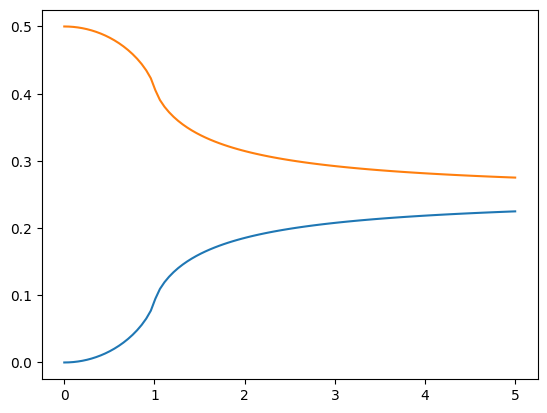

In [180]:
g = np.linspace(0,5,100)
psis =  [nq.groundstate(gi,100) for gi in g]
Ps = array([Px_n_down(s,2,[0]) for s in psis])
plot(g,Ps)
Ps = array([Px_n_down(s,2,[3]) for s in psis])

plot(g,Ps)



/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


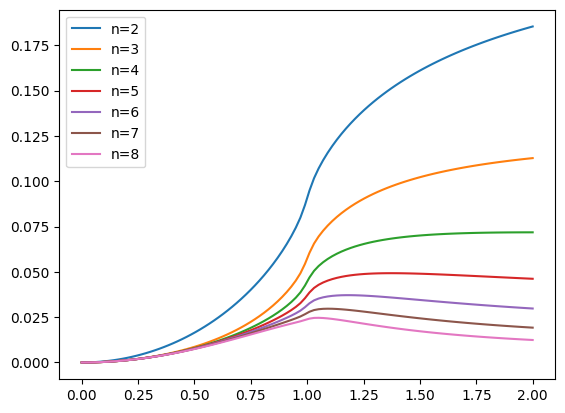

In [255]:
g = np.linspace(0,2,100)
psis =  [nq.groundstate(gi,100) for gi in g]
Ps = array([ [Px_n_down(s,n,[0]) for s in psis]  for n in ns ])
plot(g,Ps.T,label=labels)
legend()
show()

In [316]:
free_states =[ ]
free_times = []
taus_free=  [.1,1,10,25]
g0=5
gf=0.01
L=300
for tau in taus_free:
    states,t_eval = free_evo_states(tau,gf,g0,L)
    free_states.append(states)
    free_times.append(t_eval)


import analytical_quench_states as kz
taus= np.logspace(-1.5,3,100)
psi_quench_states= [kz.state(100,tau,tau) for tau in taus]





g0=1.0
g0=0.010000000000000009
g0=1.0
g0=0.010000000000000009
g0=1.0
g0=0.010000000000000009
g0=1.0
g0=0.010000000000000009


In [ ]:
ns= [2,3,4,5,6,7,8]
Ps = array([ [Px_n_down(s,n,[0]) for s in psi_quench_states] for n in ns])
plot(taus,Ps.T)



xscale("log")

In [284]:

ns= [2,3,4,5,6,7,8,10]
labels= [f"n={n}" for n in ns]
Ps = array([ [Px_n_down(s,n,[2]) for s in psi_quench_states] for n in ns[1:]])


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, 'Quench Time $\\tau$')

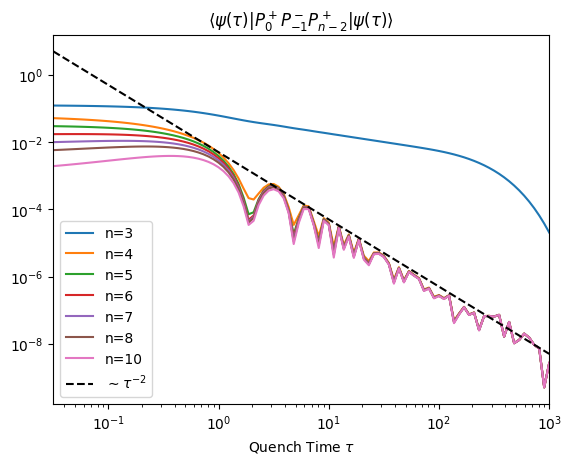

In [288]:
plot(taus,Ps.T,label=labels[1:])
title(r"$\langle \psi(\tau) | P_0^+ P_{-1}^- P^+_{n-2} | \psi(\tau) \rangle$")
#title(r"$\langle \psi(\tau) | P_0^- P^+_{n-1} | \psi(\tau) \rangle$")

xlim(taus[0],taus[-1])
#ylim(10e-4,.25)
plot(taus,1/taus**(2)/200,"--k",label=r"$\sim \tau^{-2}$")
loglog()
legend()

xlabel(r"Quench Time $\tau$")

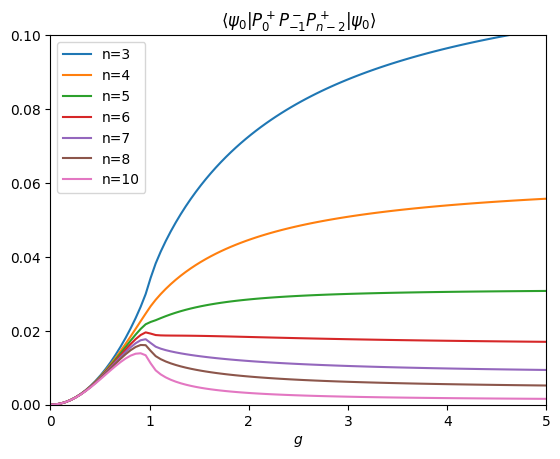

In [280]:
g = np.linspace(0,5,100)
title(r"$\langle \psi_0 | P_0^+ P_{-1}^- P^+_{n-2}  | \psi_0 \rangle$")

psis =  [nq.groundstate(gi,100) for gi in g]
Ps = array([ [Px_n_down(s,n,[1]) for s in psis]  for n in ns[1:] ])
plot(g,Ps.T,label=labels[1:])
legend()
xlabel(r"$g$")
xlim(g[0],g[-1])
ylim(0,.1)
show()

In [363]:
gs= nq.groundstate(g0,L)

In [414]:

ns= [2,3,4,5,6,7,8,10]
labels= [f"n={n}" for n in ns]
Ps = array([ [Px_n_down(s,n,[0]) for s in free_states[0]] for n in ns])
Ps_no_defects = array([ [Px_n_down(s,n,[100]) for s in free_states[0]] for n in ns])


In [415]:
nq.overlap(free_states[0],gs)

array([4.14537426e-012, 1.57217163e-013, 4.48029654e-016, 9.10213515e-020,
       1.21932228e-024, 9.68495172e-031, 3.97203654e-038, 7.05609552e-047,
       4.35639368e-057, 7.10628254e-069, 2.17847375e-082, 8.21366304e-098,
       1.78474896e-103, 3.78935270e-087, 6.82011988e-073, 1.75662358e-060,
       9.76018429e-050, 1.61783162e-040, 1.03457116e-032, 3.12879409e-026,
       5.25167087e-021, 5.53656067e-017, 4.02158685e-014, 2.14812735e-012,
       8.78477752e-012, 2.79785346e-012, 6.90259770e-014, 1.28302465e-016,
       1.70768130e-020, 1.50936233e-025, 7.99906368e-032, 2.22741087e-039,
       2.76010394e-048, 1.23909452e-058, 1.56641624e-070, 4.10337438e-084,
       1.53644450e-099, 1.39290814e-101, 2.64395069e-085, 3.74675297e-071,
       7.02493320e-059, 2.70660377e-048, 3.01942720e-039, 1.27623394e-031,
       2.52428995e-025, 2.75508031e-020, 1.88339700e-016, 8.86308035e-014,
       3.06829338e-012, 8.14291639e-012, 1.68661531e-012, 2.71465589e-014,
       3.30706012e-017, 2

In [380]:
from numpy import gradient as grad

taus_free[1]

1

(0.099, 6.382185307179586)

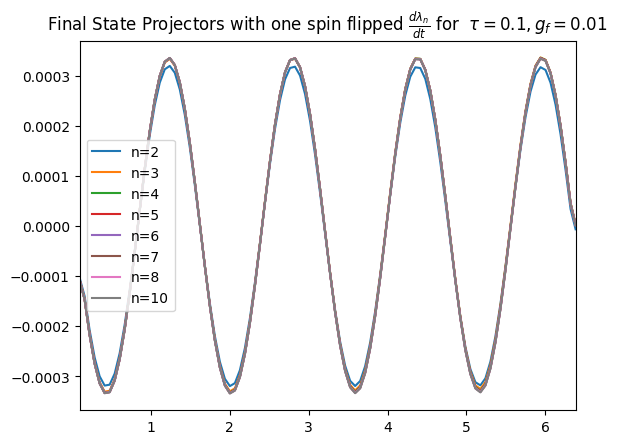

In [418]:
for pi, pd,n in zip(Ps_no_defects,Ps,ns):
    plot(free_times[0],grad(-log(pi)/n),label=f"n={n}" )
   # plot(free_times[1],grad( -log(pd)/n),label=f"n={n}" )
    #plot(free_times[1],grad( -log(nq.overlap(free_states[1],free_states[1][0]))/L/L) )

    #show()
title(r"Final State Projectors $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[0]}, g_f= {gf}$")
title(r"Final State Projectors with one spin flipped $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[0]}, g_f= {gf}$")

#plot(free_times[0],grad( -log(nq.overlap(free_states[1],gs))/L)/L,"--k",label=r"$\propto$ LE" )
legend()
xlim(free_times[0][0],free_times[0][-1])

(9.9, 16.183185307179585)

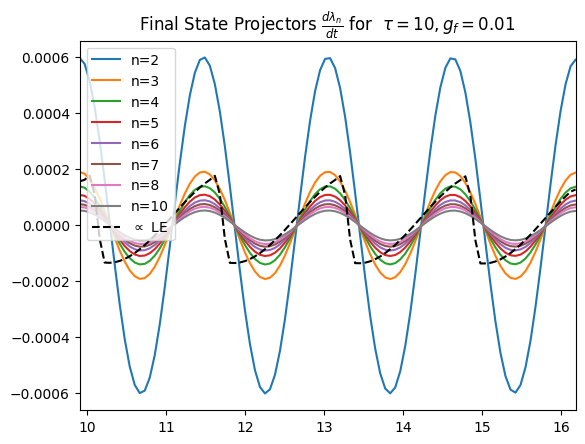

In [ ]:
for pi, pd,n in zip(Ps_no_defects,Ps,ns):
    plot(free_times[2],grad(-log(pi)/n),label=n )
    plot(free_times[2],grad( -log(pd)/n),label=f"n={n}" )
    #plot(free_times[1],grad( -log(nq.overlap(free_states[1],free_states[1][0]))/L/L) )

    #show()
title(r"Final State Projectors $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[2]}, g_f= {gf}$")

plot(free_times[2],grad( -log(nq.overlap(free_states[2],gs))/L)/(L/4),"--k",label=r"$\propto$ LE" )
#plot(free_times[2],grad( -log(nq.overlap(free_states[2],free_states[2][0]))/L/(L/4)) )

legend()
xlim(free_times[2][0],free_times[2][-1])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(24.75, 31.033185307179586)

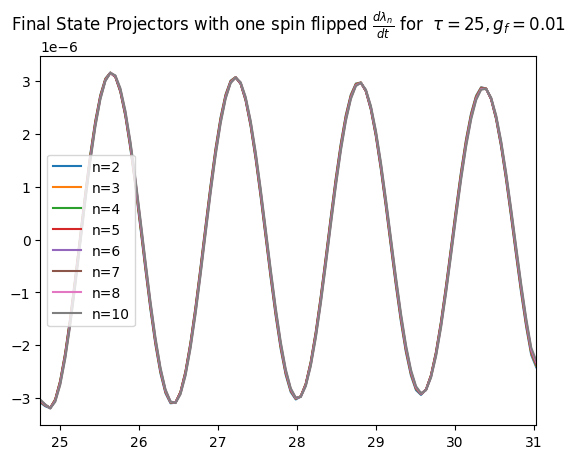

In [413]:
for pi, pd,n in zip(Ps_no_defects,Ps,ns):
    plot(free_times[3],grad(-log(pi)/n),label=f"n={n}" )
    #plot(free_times[3],grad( -log(pd)/n),label=f"n={n}" )
    #plot(free_times[1],grad( -log(nq.overlap(free_states[1],free_states[1][0]))/L/L) )

    #show()
title(r"Final State Projectors with one spin flipped $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[3]}, g_f= {gf}$")

#plot(free_times[3],grad( -log(nq.overlap(free_states[3],gs))/L)/(L/4),"--k",label=r"$\propto$ LE" )
#plot(free_times[2],grad( -log(nq.overlap(free_states[2],free_states[2][0]))/L/(L/4)) )

legend()
xlim(free_times[3][0],free_times[3][-1])

(0.099, 6.382185307179586)

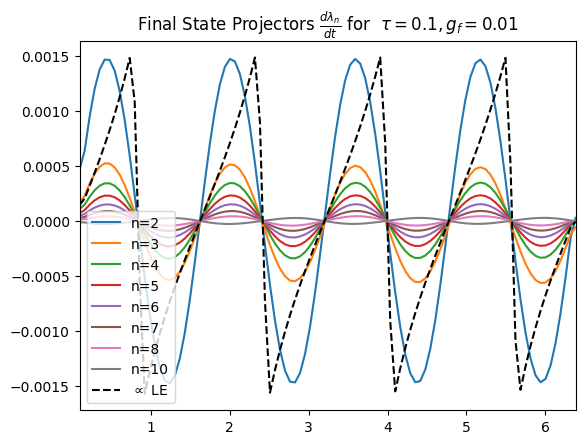

In [405]:
for pi, pd,n in zip(Ps_no_defects,Ps,ns):
    #plot(free_times[2],grad(-log(pi)/n),label=n )
    plot(free_times[0],grad( -log(pd)/n),label=f"n={n}" )
    #plot(free_times[1],grad( -log(nq.overlap(free_states[1],free_states[1][0]))/L/L) )

    #show()
title(r"Final State Projectors $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[0]}, g_f= {gf}$")

plot(free_times[0],grad( -log(nq.overlap(free_states[0],gs))/L)/(L/4),"--k",label=r"$\propto$ LE" )
#plot(free_times[2],grad( -log(nq.overlap(free_states[2],free_states[2][0]))/L/(L/4)) )

legend()
xlim(free_times[0][0],free_times[0][-1])

ValueError: x and y must have same first dimension, but have shapes (100, 3, 150) and (8, 100)

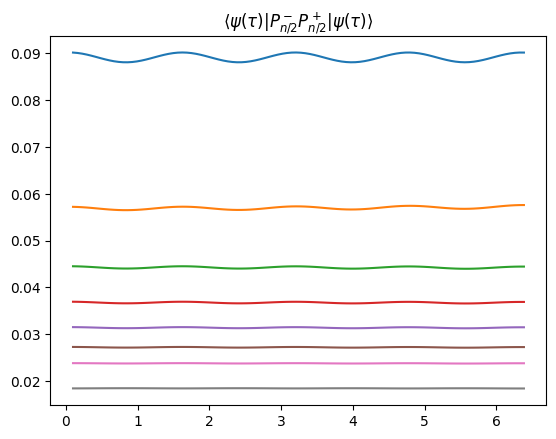

In [335]:
title(r"$\langle \psi(\tau)| P_{n/2}^- P_{n/2}^+ | \psi(\tau) \rangle$")

plot(free_times[0],Ps.T,label=labels)
plot(free_states[0],Ps_no_defects)
#plot(taus,y,label="n=6")

#plot(taus,1/2/xi,"--k")
xlim(free_times[0][0],free_times[0][-1])
legend()
xlabel(r"Quench Time $\tau$")

In [419]:
free_states =[ ]
free_times = []
taus_free=  [.1,1,10,25]
g0=5
gf=0.0
L=300
for tau in taus_free:
    states,t_eval = free_evo_states(tau,gf,g0,L)
    free_states.append(states)
    free_times.append(t_eval)


import analytical_quench_states as kz
taus= np.logspace(-1.5,3,100)
psi_quench_states= [kz.state(100,tau,tau) for tau in taus]





g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0


In [439]:
gs= nq.groundstate(g0,L)

In [442]:
theta= 0.01
ns= [2,3,4,5,6,7,8,10]
Nhat = [cos(theta),sin(theta)]
labels= [f"n={n}" for n in ns]

Ps = array([ [gp.P_generic(n,Nhat,s) for s in free_states[0]] for n in ns])


(0.1, 6.383185307179586)

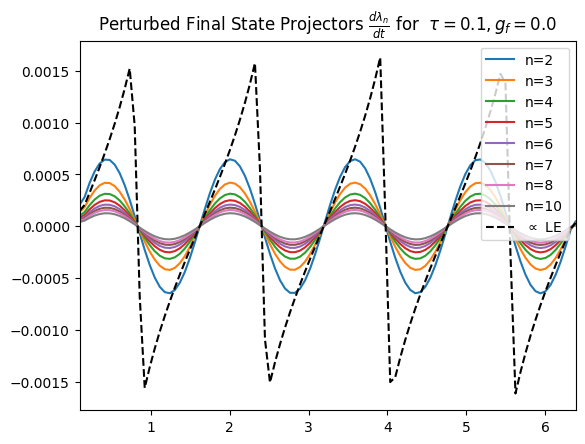

In [446]:
for pd,n in zip(Ps,ns):
    #plot(free_times[2],grad(-log(pi)/n),label=n )
    plot(free_times[0],grad( -log(pd)/n),label=f"n={n}" )
    #plot(free_times[1],grad( -log(nq.overlap(free_states[1],free_states[1][0]))/L/L) )

    #show()
title(r"Perturbed Final State Projectors $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[0]}, g_f= {gf}$")

plot(free_times[0],grad( -log(nq.overlap(free_states[0],gs))/L)/(L/4),"--k",label=r"$\propto$ LE" )
#plot(free_times[2],grad( -log(nq.overlap(free_states[2],free_states[2][0]))/L/(L/4)) )

legend()
xlim(free_times[0][0],free_times[0][-1])

(25.0, 31.283185307179586)

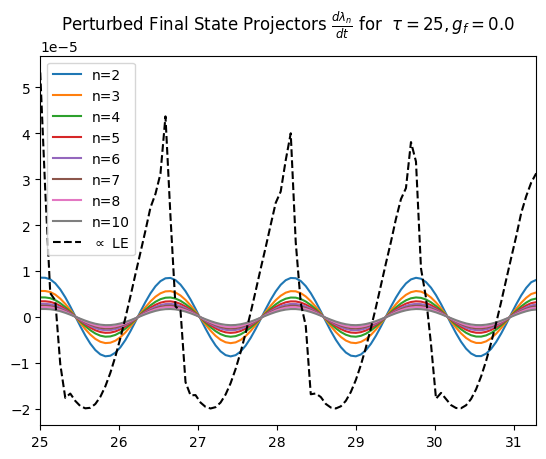

In [441]:
for pd,n in zip(Ps,ns):
    #plot(free_times[2],grad(-log(pi)/n),label=n )
    plot(free_times[-1],grad( -log(pd)/n),label=f"n={n}" )
    #plot(free_times[1],grad( -log(nq.overlap(free_states[1],free_states[1][0]))/L/L) )

    #show()
title(r"Perturbed Final State Projectors $\frac{d \lambda_n}{dt}$ for "+ rf" $\tau= {taus_free[-1]}, g_f= {gf}$")

plot(free_times[-1],grad( -log(nq.overlap(free_states[-1],gs))/L)/(L/2),"--k",label=r"$\propto$ LE" )
#plot(free_times[-1],grad( -log(nq.overlap(free_states[-1],free_states[-1][0]))/L/(L/4)),"--k" )

legend()
xlim(free_times[-1][0],free_times[-1][-1])

In [444]:
Nhat

[np.float64(0.9999500004166653), np.float64(0.009999833334166664)]